# Models non supervise

## Liste des models utilises :
    - DBSCAN
    - KMEANS
    - SpectralClustering

##### Chaque model utilise est disponible seul et avec plus de precisions dans le fichier correspondant a la racine du dossier actuel

## Import

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stop_words import get_stop_words

# Sklearn import
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD

## Models

### KMEANS

0.43525886603732616
8
Inertie correspondante : 27.93000210815725


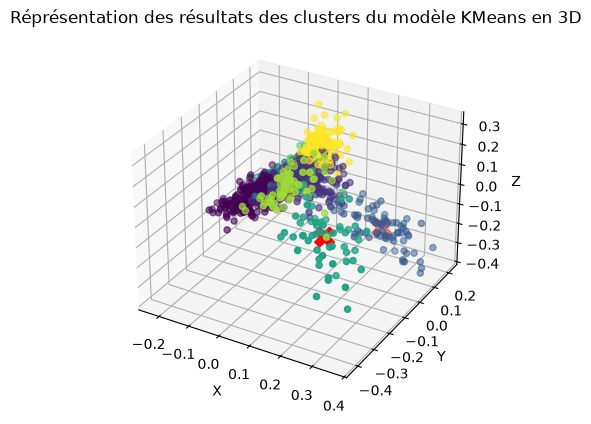

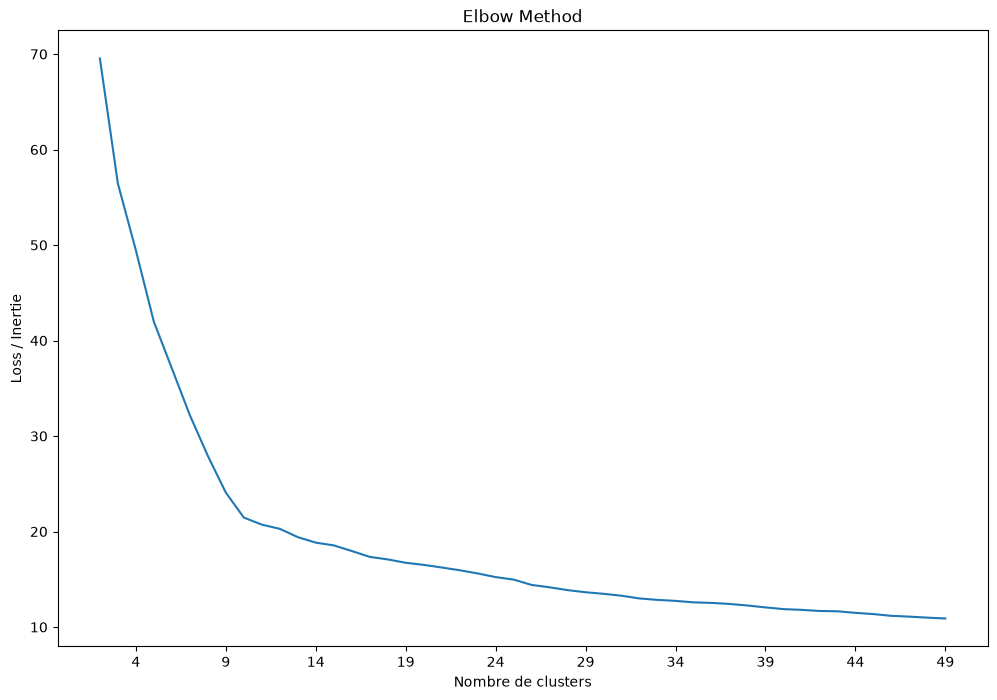

In [23]:
df = pd.read_csv("../../Student_Clean.csv")

#Récupère les textes et remplace les NA par des ""
texts = df["Temoignage"].fillna("")


#Créer mon TF-IDF (Terme frequency invert document frequency) en retirant les stop_words
vectorizer = TfidfVectorizer(stop_words="english")
X_tp = vectorizer.fit_transform(texts) #Transforme les mots en valeurs et regarde si chaque phrase possède ces mots pour leurs donner un score

# sauvegarde des valeus pour les meilleurs prametres
Best_N_Compo = 20
Best_H_Score = -1
Best_H_Key = 0
actual_N = 20
Best_inertia = 0

# Boucler sur le parametre `n_components` de `TruncatedSVD` entre 20 et 10 pour limiter les dimensions creer par le TfidfVectorizer
while actual_N >= 10:
    actual_N-=1
    # Utilisation d'un`TruncatedSVD` car le TF-IDF fait enormement de dimensions, pour garder une coherence et une faisabilite avec le miodel KMEANS on va en garder 50
    svd = TruncatedSVD(n_components=actual_N, random_state=42)
    X = svd.fit_transform(X_tp)
    
    #Test chaque nombre de clusters entre 2 et 50 puis ajoute les score dans un dico et enfin print le meilleur score de ce dico afin de connaître la meilleur valeur pour le nombre de clusters
    scores = {}
    inertias = {}
    for n in range(2, 50):
        kmeans = KMeans(
            n_clusters=n,
            random_state=0,
            n_init="auto", #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
        )
        Y = kmeans.fit_predict(X)
        inertias[f"{n}"] = kmeans.inertia_
        score = silhouette_score(X, Y, metric="cosine") # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
        scores[f"{n}"] = score
    
    highest_key = max(scores, key=scores.get)

    # si le score actuel est le meilleur jamais vu alors on sauvegarde les valeurs
    if (Best_H_Score < scores[highest_key]):
        Best_H_Score = scores[highest_key]
        Best_N_Compo = actual_N
        Best_H_Key = highest_key
        Best_inertia = inertias[highest_key]
    
    
    # ================================================================= #
    
    # Créer mon KMeans avec le meilleur nombre de clusters
    
    kmeans = KMeans(
            n_clusters=int(highest_key),
            random_state=0,
            n_init="auto" #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
        )
    
    #Entraîne le modèle sur nos témoignages d'entrée médicale à l'hôpital
    Y = kmeans.fit_predict(X)


# on affiche le meilleur resultats dans tout ca
print(Best_H_Score)
print(Best_H_Key)
print("Inertie correspondante :", Best_inertia)


#Créer la figure 
fig = plt.figure()

#Créer l'axe en 3D 
axe = fig.add_subplot(111, projection="3d")

#Le TF-IDF à potentiellement plein de dimensions genre si on lui donne 10000 mots il peut potentiellement avoir 10000 dimensions PCA fais en sorte de ne prendre qu'un représentation avec le nombre de dimensions donné
pca = PCA(n_components=3)

#Transforme le vecteur de mes textes en vecteur 3D
points_3d = pca.fit_transform(X)

#Transforme le vecteur des centroïdes de mes clusters en vecteur 3D
centroïdes_3d = pca.transform(kmeans.cluster_centers_)

#Affiche tout mes points en 3D
axe.scatter(
    points_3d[:, 0],
    points_3d[:, 1],
    points_3d[:, 2],
    c=Y
)

#Affiche tout mes centroïdes en 3D
axe.scatter(
    centroïdes_3d[:, 0],
    centroïdes_3d[:, 1],
    centroïdes_3d[:, 2],
    marker="X",
    s=200,
    c="red"
)

#Nomme les axes
plt.title('Réprésentation des résultats des clusters du modèle KMeans en 3D')
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

#Affiche le graphique
plt.show()


fig = plt.figure(figsize=(12, 8))
plt.xticks(range(2, 51, 5))
plt.plot(inertias.keys(), inertias.values())
plt.xlabel("Nombre de clusters")
plt.ylabel("Loss / Inertie")
plt.title("Elbow Method")
plt.show()



#### Verification des contenus dans les clusters

In [27]:
df["Cluster"] = Y

for i in range(int(highest_key)):
    print(f"\n CLUSTER {i} ")
    
    # on checher pour n'avoir que ceux du cluster i
    cluster_actuel = df[df["Cluster"] == i]
    
    textes = cluster_actuel["Temoignage"]
    
    # on prend les 3 premiers
    trois_premiers = textes.head(3)
    
    # on affiche les 3 premiers
    for text in trois_premiers:
        print(text)


 CLUSTER 0 
A short sprint brought on a twinge in the middle of the back of my thigh. It's tender along a band and stiffens if I sit too long.
A sudden twist while reaching for a bag made one side of my lower back feel ‘switched off' and sore. Small stabilizing movements feel shaky.
I slipped on ice and landed seated. Since then sitting on hard chairs is very uncomfortable, and leaning slightly forward helps. Standing up from sitting is a careful process.

 CLUSTER 1 
The feverish feeling eased, but I'm now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can't fill my lungs completely.
My eyelids squeeze shut in little bursts when I'm reading or in bright light. I have to blink hard to stop it and my eyes feel tired by the evening.
After my last run, I felt a sudden wheeze that made it hard to breathe; it lingered even after I stopped.

 CLUSTER 2 
I woke up with a runny nose and a sore throat, but I thought it was just a bad col

### DBSCAN

In [ ]:
dfAll = pd.read_csv('../../Student_Clean.csv')
X = dfAll['Temoignage']
df = pd.read_csv("../../Student_Clean.csv")


# on prend les temoignage et on gere les fillna au cas ou
texts = df['Temoignage'].fillna("")


# TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)


def Training(eps):
    """
    Prend en parametre `eps` un nombre float
    La fonction train le model et renvoie des valeurs textuel et chiffres pour juger de sa precision
    Elle renvoie des print textuel avec donnees
    """

    # Entrainement du model avec nos pramatres
    db = DBSCAN(eps=eps, min_samples=10).fit(X)
    labels = db.labels_
    
    # on calcule le nombre de cluster et de bruit (le bruit etant les points non present dans un cluster)
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # On ne garde que les cluster superieur a 0 pour plus de pertinence et egalement pour utiliser `silhouette_score`
    if (n_clusters_ > 1):
        print("Nombre de cluster estimes: ", n_clusters_)
        print("Nombre de point de bruit:",  % n_noise_) 
        # on calcule la silhouette (score de precision compris entre -1 et 1, 1 etant le plus precis)
        silhouette = silhouette_score(X, labels, metric="cosine")
        print("Score de precision/ accurate:", silhouette)

        # compteurs de repartition des clusters, permet d'analyser les reparition des points dans tel ou tel groupe
        valeurs, comptes = np.unique(labels, return_counts=True)
        print("Repartitions des clusters:")
        for val, compte in zip(valeurs, comptes):
            print(f"Cluster {val} : {compte} points")


# borne finale 
end = 2
# borne de debut
tp = 0.01

# sauvegarde du meilleur parametre eps
best_eps = 0
best_value = -1

# boucle qui va appeller la fonction d'entrainement en ajoutant 0.01 en eps
while (tp < end):
    esp_Resultat, silhouette_Resultat = Training(tp)
    if (silhouette_Resultat > best_value):
        best_value = silhouette_Resultat
        best_eps = esp_Resultat
    
    tp += 0.01

print(best_eps)




# on passe sur 2 axe principale sinon le graphique ne va pas reussir a afficher nos data
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X)

couleurs_hex = df['Temoignage'] 


plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

plt.title("Visualisation en 2D des témoignages patients")
plt.xlabel("Variation 1")
plt.ylabel("Variation 2")
plt.show()

### SpectralClustering

0.037886325156468975
0.037886325156468975
0.037886325156468975
0.03739270585226559
0.03739270585226559
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
49


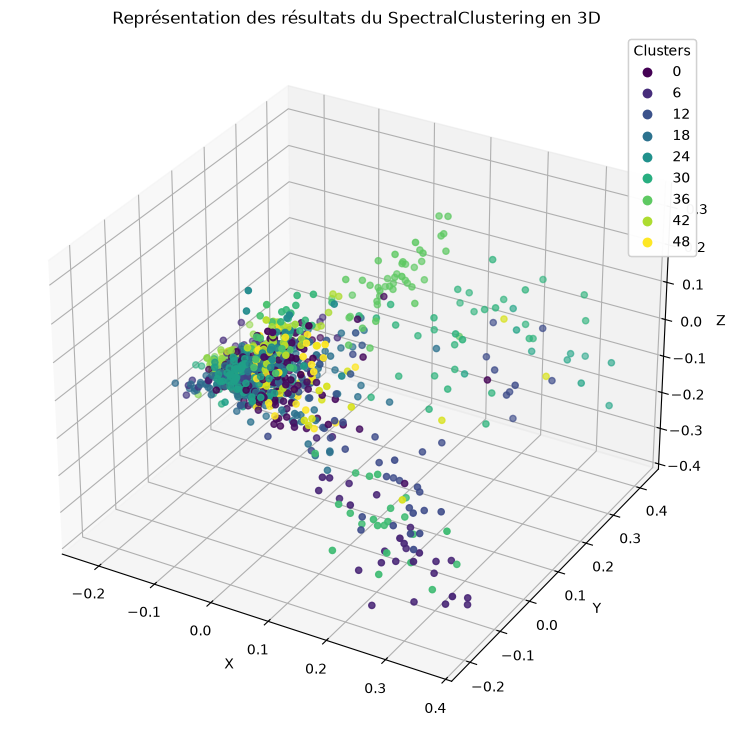

In [6]:
df = pd.read_csv("../../Student_Clean.csv")

texts = df["Temoignage"].fillna("")

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)

scores = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=n,
        random_state=0,
        n_init=2,
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y) # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
    scores[f"{n}"] = score

highest_key = max(scores, key=scores.get)

scores2 = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=int(highest_key),
        random_state=0,
        n_init=n, #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y) # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
    scores2[f"{n}"] = score
    print(score)

highest_key2 = max(scores, key=scores.get)

print(highest_key2)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA

from mpl_toolkits.mplot3d import Axes3D

model = SpectralClustering(
    n_clusters=int(highest_key),
    random_state=0,
    n_init=int(highest_key2)
)

#Récupérer le cluster de chaque témoignage
Y = model.fit_predict(X)


#Réduire les données à 3 dimensions
pca = PCA(n_components=3)

X_3D = pca.fit_transform(X.toarray())


#Créer le graphique
fig = plt.figure(figsize=(12, 9))

axe = fig.add_subplot(111, projection="3d")


#Afficher les points
scatter = axe.scatter(
    X_3D[:, 0],
    X_3D[:, 1],
    X_3D[:, 2],
    c=Y,
)


#Nomme les axes
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

plt.title("Représentation des résultats du SpectralClustering en 3D")

#Légende des clusters
legend = axe.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

axe.add_artist(legend)


plt.show()



## Comparaison

Nous allons donc maintenant comparer nos 3 models car leurs resultats sont bien differents.
